In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import scipy.stats as stats

from data_generation_simulation import simulate_chemo_proteinlevel_nonparametric
from FourPL_model_fit import four_pl_fit_logscale
from IR_model_fit_logscale import isotonic_regression_fit_logscale
from Model_eval_IR_4PL import evaluate_model_fit

from plot_confusion_matrix import plot_confusion_matrix
from plot_roc_curve import plot_roc_curve
from plot_simulation_curve import plot_simulation_curve

In [2]:
#simulate data -- 

# read in bio data to be used for simulations 
bio_data_template_1 = pd.read_csv("bio_template1.csv")

# define protein template for strong, weak, and non interactions
protein_template = {
    "strong_interaction": bio_data_template_1[bio_data_template_1['interaction_type'] == 'strong_interaction'],
    "weak_interaction": bio_data_template_1[bio_data_template_1['interaction_type'] == 'weak_interaction'],
    "no_interaction": bio_data_template_1[bio_data_template_1['interaction_type'] == 'no_interaction']
}

# sim data1: n= 5000; no outliers, 3 reps 
sim_data1 = simulate_chemo_proteinlevel_nonparametric(
    N_proteins=5000,
    TP=0.001,
    TW=0.009,
    TN=0.99,
    rep=3,
    seed=15,
    var_tech=0.25,
    template=protein_template,
    outlier_prob=0
)

# sim data2: n= 5000; no outliers, 3 reps, 5% outlier 
sim_data2 = simulate_chemo_proteinlevel_nonparametric(
    N_proteins=5000,
    TP=0.001,
    TW=0.009,
    TN=0.99,
    rep=3,
    seed=15,
    var_tech=0.25,
    template=protein_template,
    outlier_prob=0.05
)
# sim data3: n= 5000; no outliers, 3 reps, var = 0.8 
sim_data3 = simulate_chemo_proteinlevel_nonparametric(
    N_proteins=5000,
    TP=0.001,
    TW=0.009,
    TN=0.99,
    rep=3,
    seed=15,
    var_tech=.8,
    template=protein_template,
    outlier_prob=0
)

# sim data4: n= 5000; no outliers, 3 reps, 4 doses (two low, two high), var = 0.25 
sim_data4 = simulate_chemo_proteinlevel_nonparametric(
    N_proteins=5000,
    TP=0.001,
    TW=0.009,
    TN=0.99,
    rep=3,
    concentrations= (0,1, 1000, 3000),
    seed=15,
    var_tech=0.25,
    template=protein_template,
    outlier_prob=0
)

# sim data5: n= 5000; 2 rep, 0.8 var
sim_data5 = simulate_chemo_proteinlevel_nonparametric(
    N_proteins=5000,
    TP=0.001,
    TW=0.009,
    TN=0.99,
    rep=2,
    seed=15,
    var_tech=0.8,
    template=protein_template,
    outlier_prob=0
)

# sim data6: n= 5000; 1 rep, 0.8 var
sim_data6 = simulate_chemo_proteinlevel_nonparametric(
    N_proteins=5000,
    TP=0.001,
    TW=0.009,
    TN=0.99,
    rep=1,
    seed=15,
    var_tech=0.8,
    template=protein_template,
    outlier_prob=0
)

Part 1 & 2: Fit Isotonic Regression and Four Parameter Logistic Regression 

In [8]:
# fit isotonic regression model on all datasets 
IR_model_res_all = []
data_list = [sim_data1, sim_data2, sim_data3, sim_data4, sim_data5]

for dataset in data_list:
    model = evaluate_model_fit(dataset, 
                               method='IR')
    IR_model_res_all.append(model)

Number of sig proteins (p < .05): 56
Number of sig proteins with FDR adjustment (p < .05): 33
Strong interaction hits: 5
Weak interaction hits: 28
No interaction hits: 0
Number of sig proteins (p < .05): 39
Number of sig proteins with FDR adjustment (p < .05): 19
Strong interaction hits: 5
Weak interaction hits: 14
No interaction hits: 0
Number of sig proteins (p < .05): 9
Number of sig proteins with FDR adjustment (p < .05): 5
Strong interaction hits: 5
Weak interaction hits: 0
No interaction hits: 0
Number of sig proteins (p < .05): 202
Number of sig proteins with FDR adjustment (p < .05): 23
Strong interaction hits: 5
Weak interaction hits: 15
No interaction hits: 3
Number of sig proteins (p < .05): 8
Number of sig proteins with FDR adjustment (p < .05): 3
Strong interaction hits: 3
Weak interaction hits: 0
No interaction hits: 0


In [9]:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# fit four parameterlogistic model on all datasets 
FourPL_res_all   = []
data_list = [sim_data1, sim_data2, sim_data3, sim_data4, sim_data5, sim_data6]

for dataset in data_list:
    model = evaluate_model_fit(dataset, 
                               method='Four_PL')
    FourPL_res_all.append(model)
 



Number of sig proteins (p < .05): 178
Number of sig proteins with FDR adjustment (p < .05): 26
Strong interaction hits: 5
Weak interaction hits: 21
No interaction hits: 0
Number of sig proteins (p < .05): 194
Number of sig proteins with FDR adjustment (p < .05): 14
Strong interaction hits: 5
Weak interaction hits: 9
No interaction hits: 0
Number of sig proteins (p < .05): 127
Number of sig proteins with FDR adjustment (p < .05): 6
Strong interaction hits: 4
Weak interaction hits: 0
No interaction hits: 2
Number of sig proteins (p < .05): 79
Number of sig proteins with FDR adjustment (p < .05): 5
Strong interaction hits: 4
Weak interaction hits: 1
No interaction hits: 0
Number of sig proteins (p < .05): 122
Number of sig proteins with FDR adjustment (p < .05): 4
Strong interaction hits: 2
Weak interaction hits: 0
No interaction hits: 2
Number of sig proteins (p < .05): 163
Number of sig proteins with FDR adjustment (p < .05): 3
Strong interaction hits: 2
Weak interaction hits: 0
No inte

Part 3: Create Feedfoward Neural Network 

In [11]:
def prep_fnn_dataset(df, response_type="log_intensity", label_type="binary"):
    """
    input:
    - df: input DataFrame
    - response_type: "log_intensity" or "ratio"
    - label_type: "binary" or "multiclass"

    output:
    - X: ndarray of shape (n_samples, 9)
    - y: ndarray of shape (n_samples,)
    """
    dose_levels = sorted(df['dose'].unique())
    X, y = [], []

    for protein in df['protein'].unique():
        protein_df = df[df['protein'] == protein].copy()

        if response_type == "log_intensity":
            feature_col = "log_intensity"
        else:
            protein_df['intensity'] = 2**protein_df['log_intensity']
            dmso_mean = protein_df[protein_df['sample_group'] == 'DMSO']['intensity'].mean()
            protein_df['ratio'] = protein_df['intensity'] / dmso_mean 
            feature_col = "ratio"

        for rep in protein_df['replicate'].unique():
            rep_df = protein_df[protein_df['replicate'] == rep]
            vec = rep_df.set_index("dose").loc[dose_levels, feature_col].values

            if len(vec) != 9 or np.isnan(vec).any():
                continue  # skip incomplete

            label = protein_df['protein_group'].iloc[0]
            if label_type == "binary":
                y_val = 1 if label in ['strong_interaction', 'weak_interaction'] else 0
            else:
                y_val = {'no_interaction': 0, 'weak_interaction': 1, 'strong_interaction': 2}[label]

            X.append(vec)
            y.append(y_val)

    return np.array(X), np.array(y)


In [12]:
class FNN(nn.Module):
    def __init__(self, input_size, hidden_dim=32, output_dim=1):  
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x)).squeeze()


In [13]:
def train_fnn(X, y, epochs=20, batch_size=16):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = FNN(input_size=X.shape[1])
    criterion = nn.BCELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    return model, loss_history


In [14]:
def plot_training_loss(losses):
    plt.figure(figsize=(6, 4))
    plt.plot(losses, marker='o')
    plt.title("Training Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [16]:
def FNN_full_implementation(sim_dataset):
    
    # split by protein into training and test dataset (i.e. 20% proteins left out to predict)
    simulation_dataset = sim_dataset

    protein_meta = simulation_dataset[['protein', 'protein_group']].drop_duplicates()

    protein_meta['label'] = protein_meta['protein_group'].map(
        lambda x: 1 if x in ['strong_interaction', 'weak_interaction'] else 0
    )

    # split into training and test data by protein name 
    train_proteins, test_proteins = train_test_split(
        protein_meta['protein'], 
        test_size=0.2, 
        stratify=protein_meta['label'], 
        random_state=42
    )

    train_df = simulation_dataset[simulation_dataset['protein'].isin(train_proteins)]
    test_df  = simulation_dataset[simulation_dataset['protein'].isin(test_proteins)]

    # format for FNN
    X_train, y_train = prep_fnn_dataset(train_df, response_type="ratio", label_type="binary")
    X_test, y_test   = prep_fnn_dataset(test_df,  response_type="ratio", label_type="binary")

    ## Train FNN and compute all metrics and visualize  ##
    model, loss_history = train_fnn(X_train, y_train, epochs=10)

    # compute y predictions
    model.eval()
    with torch.no_grad():
        y_pred_probs = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
        y_pred = (y_pred_probs > 0.5).astype(int) 


    ### Number of Protein Hits per Group  ###
    unique_proteins_df = test_df[['protein','replicate', 'protein_group']].drop_duplicates()
    unique_proteins_df['predicted_hit'] = y_pred


    total_counts = (
        unique_proteins_df
        .groupby('protein_group')
        .size()
        .reset_index(name='total_proteins')
    )

    hit_counts = (
        unique_proteins_df[unique_proteins_df['predicted_hit'] == 1]
        .groupby('protein_group')
        .size()
        .reset_index(name='num_hits')
    )

    # Merge the two tables
    hits_by_group = pd.merge(hit_counts, total_counts, on='protein_group', how='right')
    hits_by_group['num_hits'] = hits_by_group['num_hits'].fillna(0).astype(int)

    hits_by_group['hit_rate'] = hits_by_group['num_hits'] / hits_by_group['total_proteins']

    print(hits_by_group)


    ### LOSS and ROC curve visualization ###
    plot_training_loss(loss_history)
    plot_roc_curve(model, X_train, y_train, X_test, y_test)

    # additional metrics - 
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_pred_probs)) 

Epoch 1/10, Loss: 0.0913
Epoch 2/10, Loss: 0.0439
Epoch 3/10, Loss: 0.0343
Epoch 4/10, Loss: 0.0255
Epoch 5/10, Loss: 0.0188
Epoch 6/10, Loss: 0.0147
Epoch 7/10, Loss: 0.0122
Epoch 8/10, Loss: 0.0105
Epoch 9/10, Loss: 0.0095
Epoch 10/10, Loss: 0.0088
        protein_group  num_hits  total_proteins  hit_rate
0      no_interaction         0            2970  0.000000
1  strong_interaction         3               3  1.000000
2    weak_interaction        13              27  0.481481


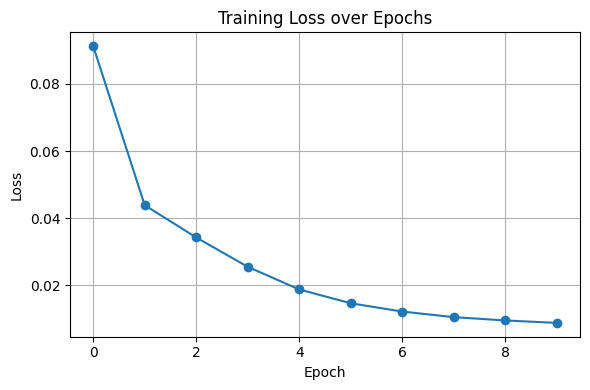

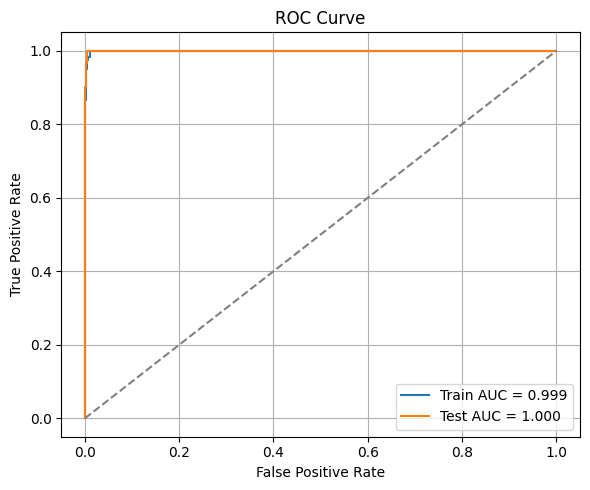

Accuracy: 0.9953333333333333
Precision: 1.0
Recall: 0.5333333333333333
F1 Score: 0.6956521739130435
AUC: 0.9995510662177328
Epoch 1/10, Loss: 0.1100
Epoch 2/10, Loss: 0.0502
Epoch 3/10, Loss: 0.0478
Epoch 4/10, Loss: 0.0445
Epoch 5/10, Loss: 0.0414
Epoch 6/10, Loss: 0.0465
Epoch 7/10, Loss: 0.0358
Epoch 8/10, Loss: 0.0319
Epoch 9/10, Loss: 0.0294
Epoch 10/10, Loss: 0.0271
        protein_group  num_hits  total_proteins  hit_rate
0      no_interaction         0            2970       0.0
1  strong_interaction         3               3       1.0
2    weak_interaction         0              27       0.0


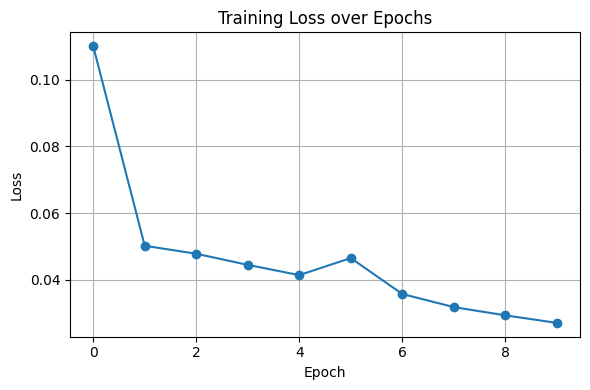

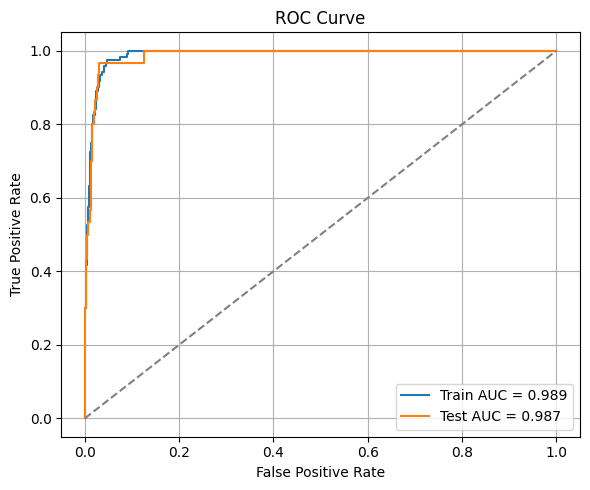

Accuracy: 0.991
Precision: 1.0
Recall: 0.1
F1 Score: 0.18181818181818182
AUC: 0.9871717171717171
Epoch 1/10, Loss: 0.1115
Epoch 2/10, Loss: 0.0576
Epoch 3/10, Loss: 0.0537
Epoch 4/10, Loss: 0.0507
Epoch 5/10, Loss: 0.0495
Epoch 6/10, Loss: 0.0492
Epoch 7/10, Loss: 0.0488
Epoch 8/10, Loss: 0.0478
Epoch 9/10, Loss: 0.0483
Epoch 10/10, Loss: 0.0481
        protein_group  num_hits  total_proteins  hit_rate
0      no_interaction         0            2970       0.0
1  strong_interaction         0               3       0.0
2    weak_interaction         0              27       0.0


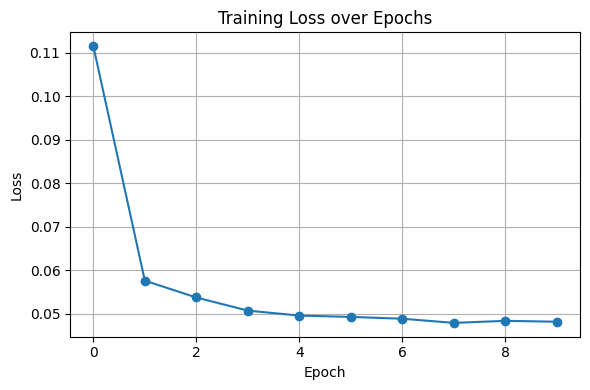

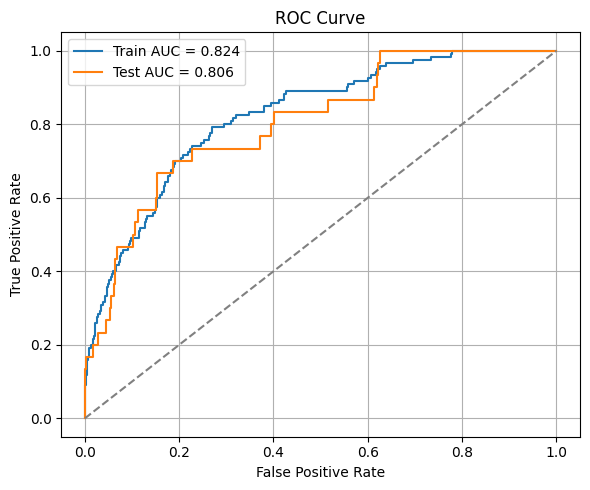

Accuracy: 0.99
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC: 0.8060381593714927
Epoch 1/10, Loss: 0.1415
Epoch 2/10, Loss: 0.0600
Epoch 3/10, Loss: 0.0567
Epoch 4/10, Loss: 0.0541
Epoch 5/10, Loss: 0.0528
Epoch 6/10, Loss: 0.0520
Epoch 7/10, Loss: 0.0513
Epoch 8/10, Loss: 0.0508
Epoch 9/10, Loss: 0.0508
Epoch 10/10, Loss: 0.0505
        protein_group  num_hits  total_proteins  hit_rate
0      no_interaction         0            1980       0.0
1  strong_interaction         0               2       0.0
2    weak_interaction         0              18       0.0


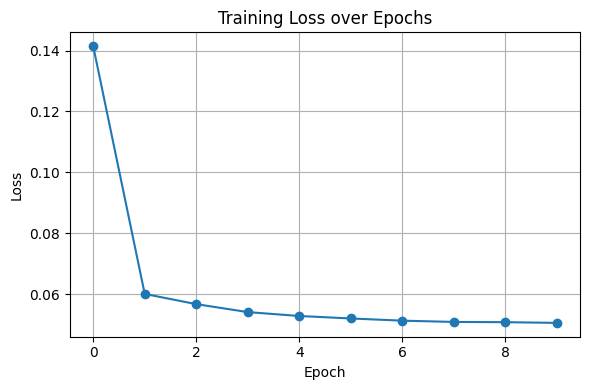

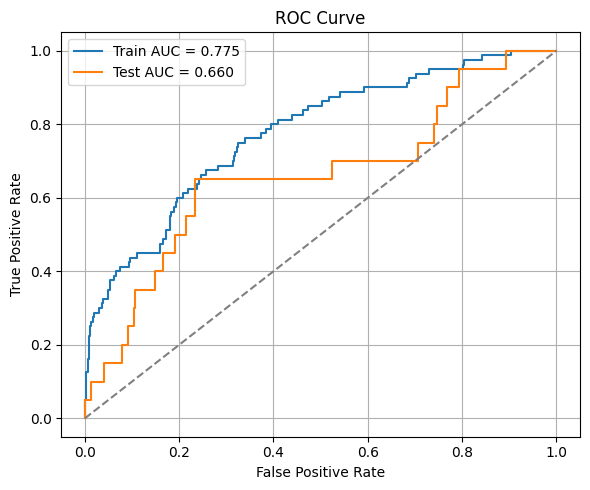

Accuracy: 0.99
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC: 0.6603282828282828
Epoch 1/10, Loss: 0.2155
Epoch 2/10, Loss: 0.0741
Epoch 3/10, Loss: 0.0680
Epoch 4/10, Loss: 0.0614
Epoch 5/10, Loss: 0.0562
Epoch 6/10, Loss: 0.0526
Epoch 7/10, Loss: 0.0503
Epoch 8/10, Loss: 0.0494
Epoch 9/10, Loss: 0.0481
Epoch 10/10, Loss: 0.0477
        protein_group  num_hits  total_proteins  hit_rate
0      no_interaction         0             990       0.0
1  strong_interaction         0               1       0.0
2    weak_interaction         0               9       0.0


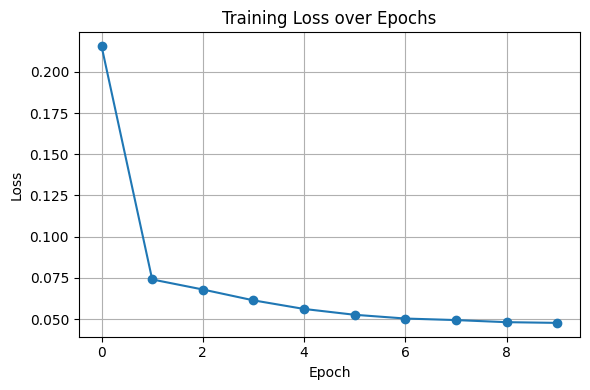

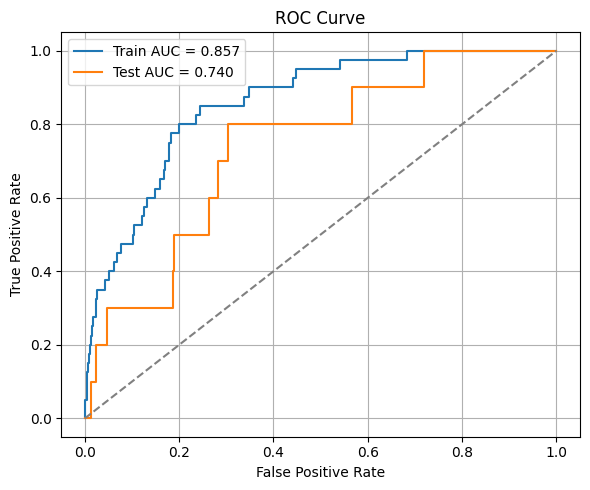

Accuracy: 0.99
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC: 0.7404040404040404


In [48]:
# fit FNN on all datasets 
FFN_res_all   = []
data_list = [sim_data1, sim_data2, sim_data3, sim_data5, sim_data6]

for dataset in data_list:
    model = FNN_full_implementation(dataset)
    FFN_res_all.append(model)
 

In [53]:
tp_all = {
    'SimData1': {
        'IR':   {'strong': 5, 'weak': 28, 'none': 0},
        '4PL':  {'strong': 5, 'weak': 21, 'none': 0},
        'FNN':  {'strong': 3, 'weak': 13, 'none': 0}
    },
    'SimData2': {
        'IR':   {'strong': 5, 'weak': 14, 'none': 0},
        '4PL':  {'strong': 5, 'weak': 9,  'none': 0},
        'FNN':  {'strong': 3, 'weak': 0,  'none': 0}
    },
    'SimData3': {
        'IR':   {'strong': 5, 'weak': 0,  'none': 0},
        '4PL':  {'strong': 4, 'weak': 0,  'none': 2},
        'FNN':  {'strong': 0, 'weak': 0,  'none': 0}
    },
    'SimData4': {
        'IR':   {'strong': 5, 'weak': 15, 'none': 3},
        '4PL':  {'strong': 4, 'weak': 1,  'none': 0},
        # FNN not applicable
    },
    'SimData5': {
        'IR':   {'strong': 3, 'weak': 0,  'none': 0},
        '4PL':  {'strong': 2, 'weak': 0,  'none': 2},
        'FNN':  {'strong': 0, 'weak': 0,  'none': 0}
    },
    'SimData6': {
        # IR not applicable
        '4PL':  {'strong': 2, 'weak': 0,  'none': 1},
        'FNN':  {'strong': 0, 'weak': 0,  'none': 0}
    }
}

pred_all = {
    'SimData1': {
        'IR':   {'strong': 5, 'weak': 28, 'none': 3},
        '4PL':  {'strong': 5, 'weak': 21, 'none': 2},
        'FNN':  {'strong': 3, 'weak': 13, 'none': 0}
    },
    'SimData2': {
        'IR':   {'strong': 5, 'weak': 14, 'none': 0},
        '4PL':  {'strong': 5, 'weak': 9,  'none': 0},
        'FNN':  {'strong': 3, 'weak': 0,  'none': 0}
    },
    'SimData3': {
        'IR':   {'strong': 5, 'weak': 0,  'none': 0},
        '4PL':  {'strong': 4, 'weak': 0,  'none': 2},
        'FNN':  {'strong': 0, 'weak': 0,  'none': 0}
    },
    'SimData4': {
        'IR':   {'strong': 5, 'weak': 15, 'none': 3},
        '4PL':  {'strong': 4, 'weak': 1,  'none': 0},
        # FNN not applicable
    },
    'SimData5': {
        'IR':   {'strong': 3, 'weak': 0,  'none': 0},
        '4PL':  {'strong': 2, 'weak': 0,  'none': 2},
        'FNN':  {'strong': 0, 'weak': 0,  'none': 0}
    },
    'SimData6': {
        # IR not applicable
        '4PL':  {'strong': 2, 'weak': 0,  'none': 1},
        'FNN':  {'strong': 0, 'weak': 0,  'none': 0}
    }
}


Figure saved to: protein_group_recall.pdf


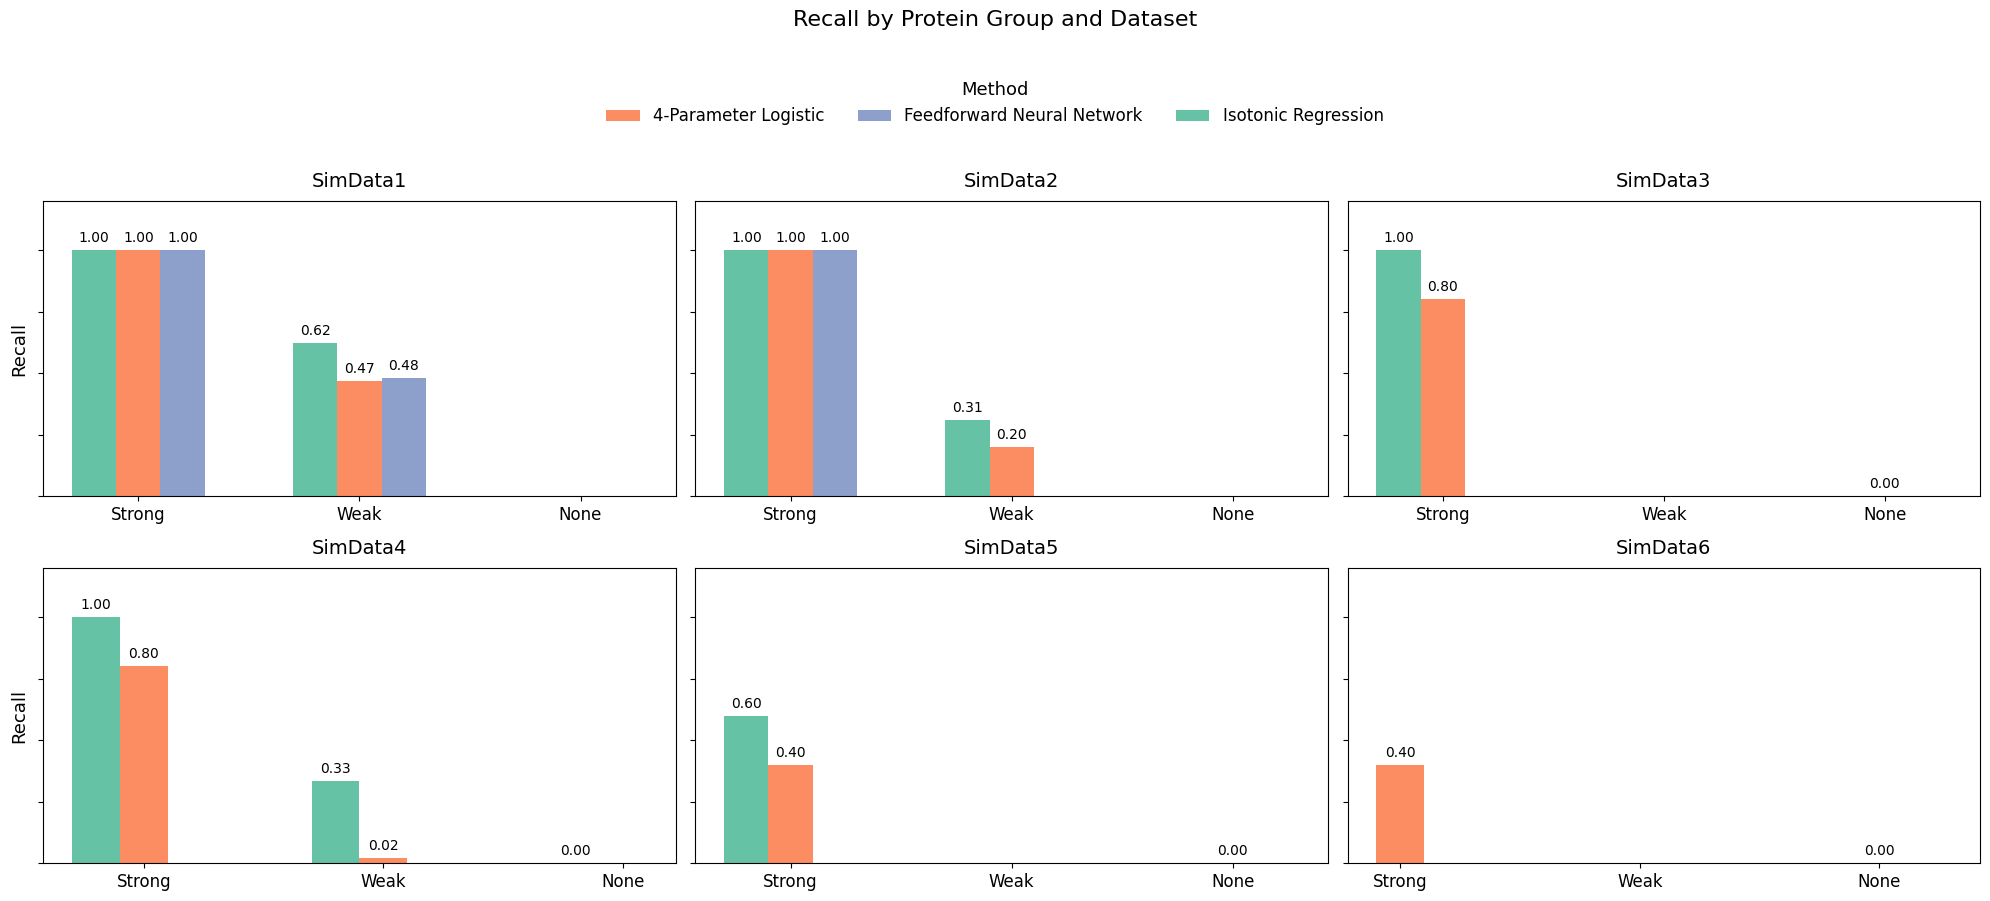

In [89]:
total_true_dict_per_model = {
    'IR':   {'strong': 5, 'weak': 45, 'none': 4950},
    '4PL':  {'strong': 5, 'weak': 45, 'none': 4950},
    'FNN':  {'strong': 3, 'weak': 27, 'none': 2970}
}

plot_recall_by_dataset(tp_all, total_true_dict_per_model,filename= 'protein_group_recall.pdf')


In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_recall_by_dataset(tp_all, total_true_dict_per_model, title="Recall by Protein Group and Dataset", filename = None):
    """
    Publication-quality plot: recall per protein group across models, with full method names in the legend.
    """
    datasets = list(tp_all.keys())
    models = sorted(set(m for ds in tp_all.values() for m in ds.keys()))
    groups = ['Strong', 'Weak', 'None']
    group_keys = ['strong', 'weak', 'none']

    # Full names for legend
    model_fullnames = {
        'IR': 'Isotonic Regression',
        '4PL': '4-Parameter Logistic',
        'FNN': 'Feedforward Neural Network'
    }
    colors = {
        'IR': '#66c2a5',
        '4PL': '#fc8d62',
        'FNN': '#8da0cb'
    }

   # fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
    fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharey=True)

    axes = axes.flatten()

    width = 0.2
    model_offsets = {'IR': -width, '4PL': 0, 'FNN': width}

    for i, dataset in enumerate(datasets):
        ax = axes[i]
        ax.set_title(dataset, fontsize=14, pad=10)
        x = np.arange(len(groups))
        ax.set_xticks(x)
        ax.set_xticklabels(groups, fontsize=12)
        ax.set_ylim(0, 1.2)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels([f"{y:.0%}" for y in [0, 0.25, 0.5, 0.75, 1.0]], fontsize=11)
        if i in [0, 3]:
            ax.set_ylabel("Recall", fontsize=13)
        else:
            ax.set_yticklabels([])

        for model in models:
            if model not in tp_all[dataset]:
                continue
            recalls = []
            for gk in group_keys:
                tp = tp_all[dataset][model].get(gk, 0)
                total = total_true_dict_per_model[model].get(gk, 1)
                recall = tp / total if total > 0 else 0
                recalls.append(recall)

            bar_pos = x + model_offsets[model]
            bars = ax.bar(bar_pos, recalls, width=width, color=colors[model],
                          label=model_fullnames[model] if i == 0 else "")

            # Optional: annotate values on bars
            for bar, val in zip(bars, recalls):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
                            ha='center', va='bottom', fontsize=10)


    # Create unified legend with full method names
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Method",
        loc='upper center',
        ncol=3,
        frameon=False,
        fontsize=12,
        title_fontsize=13,
        bbox_to_anchor=(0.5, 1.05)  # <--- Moves the legend down slightly
    )

    # Title pushed slightly higher
    fig.suptitle(title, fontsize=16, y=1.12)

    # Reserve more space for title + legend
    plt.tight_layout(rect=[0, 0, 1, 0.98])  # keep this below everything else

   # fig.suptitle(title, fontsize=16, y=1.04)
    #plt.tight_layout(rect=[0, 0, 1, 0.98])

    if filename:
        fig.savefig(filename, format = "pdf")
        print(f"Figure saved to: {filename}")

    plt.show()
